# K. pneumoniae AMR Data Extraction Pipeline
### Querying BV-BRC, downloading genome sequences, and preparing clean labeled data

This notebook covers:
- Querying the BV-BRC API for K. pneumoniae meropenem resistance data
- Downloading whole genome FASTA sequences for 726 labeled isolates
- Data cleaning, label encoding, and saving to Google Drive

In [ ]:
# Install required libraries
!pip install biopython -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import os

print("Libraries loaded successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 50.4 MB/s eta 0:00:00
Libraries loaded successfully


## Step 1 - Query BV-BRC API

In [ ]:
from io import StringIO

print("Querying BV-BRC API for K. pneumoniae meropenem AMR data...")

# Correct BV-BRC API query
# genome_name contains the organism name
# We use eq() for exact match and keyword() for partial match
url = "https://bv-brc.org/api/genome_amr/"

# Build query with correct field names and proper encoding
query = "eq(genome_name,Klebsiella%20pneumoniae)&eq(antibiotic,meropenem)&select(genome_id,genome_name,antibiotic,resistant_phenotype,laboratory_typing_method,isolation_country)&limit(5000)"

full_url = f"{url}?{query}"

response = requests.get(
    full_url,
    headers={"Accept": "text/tsv"},
    timeout=120
)

print(f"Status code: {response.status_code}")
print(f"Response size: {len(response.content)} bytes")
print(f"\nFirst 300 characters:")
print(response.text[:300])

Querying BV-BRC API for K. pneumoniae meropenem AMR data...
Status code: 200
Response size: 459396 bytes

First 300 characters:
genome_id	genome_name	antibiotic	resistant_phenotype	laboratory_typing_method	isolation_country
"573.18699"	"Klebsiella pneumoniae strain Klebsiella pneumoniae 1000"	"meropenem"	"Resistant"		
"573.18698"	"Klebsiella pneumoniae strain Klebsiella pneumoniae 1074"	"meropenem"	"Resistant"		
"573.31049"	


## Step 2 - Explore and Clean Labels

In [ ]:
# Parse the TSV response directly into a dataframe
# StringIO converts the text response into a file-like object pandas can read

from io import StringIO

df = pd.read_csv(StringIO(response.text), sep='\t')

print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head())

Shape: (5000, 6)

Columns: ['genome_id', 'genome_name', 'antibiotic', 'resistant_phenotype', 'laboratory_typing_method', 'isolation_country']

First 5 rows:
   genome_id                                        genome_name antibiotic  \
0  573.18699  Klebsiella pneumoniae strain Klebsiella pneumo...  meropenem   
1  573.18698  Klebsiella pneumoniae strain Klebsiella pneumo...  meropenem   
2  573.31049  Klebsiella pneumoniae strain Klebsiella pneumo...  meropenem   
3  573.18697  Klebsiella pneumoniae strain Klebsiella pneumo...  meropenem   
4  573.27574  Klebsiella pneumoniae strain Klebsiella_pneumo...  meropenem   

  resistant_phenotype laboratory_typing_method  isolation_country  
0           Resistant                      NaN                NaN  
1           Resistant                      NaN                NaN  
2         Susceptible                      NaN                NaN  
3           Resistant                      NaN                NaN  
4         Susceptible             

In [ ]:
# Check resistance phenotype distribution
# This tells us our class balance before we do anything else

print("Resistance phenotype distribution:")
print(df['resistant_phenotype'].value_counts())

print(f"\nTotal genomes: {len(df)}")
print(f"\nMissing phenotype labels:")
print(df['resistant_phenotype'].isna().sum())

# Check isolation country
print(f"\nTop 10 isolation countries:")
print(df['isolation_country'].value_counts().head(10))

Resistance phenotype distribution:
resistant_phenotype
Susceptible     1564
Resistant        620
Intermediate       2
Name: count, dtype: int64

Total genomes: 5000

Missing phenotype labels:
2814

Top 10 isolation countries:
Series([], Name: count, dtype: int64)


In [ ]:

# Drop rows with no resistance label
df_labeled = df.dropna(subset=['resistant_phenotype'])
print(f"Rows with labels: {len(df_labeled)}")

# Drop Intermediate - only 2 rows, ambiguous clinically
df_clean = df_labeled[
    df_labeled['resistant_phenotype'].isin(['Resistant', 'Susceptible'])
]
print(f"After dropping Intermediate: {len(df_clean)}")

# Final class balance
counts = df_clean['resistant_phenotype'].value_counts()
total = len(df_clean)
print(f"\nFinal class balance:")
print(f"  Susceptible: {counts['Susceptible']} ({round(counts['Susceptible']/total*100, 1)}%)")
print(f"  Resistant:   {counts['Resistant']} ({round(counts['Resistant']/total*100, 1)}%)")
print(f"  Total usable genomes: {total}")

# Encode labels as binary — standard ML format
# Resistant = 1, Susceptible = 0
df_clean = df_clean.copy()
df_clean['label'] = df_clean['resistant_phenotype'].map({
    'Resistant': 1,
    'Susceptible': 0
})

print(f"\nLabel encoding check:")
print(df_clean[['resistant_phenotype', 'label']].value_counts())

# Save clean metadata
df_clean.to_csv("kpn_meropenem_clean.csv", index=False)
print(f"\nClean metadata saved — {len(df_clean)} genomes ready")

Rows with labels: 2186
After dropping Intermediate: 2184

Final class balance:
  Susceptible: 1564 (71.6%)
  Resistant:   620 (28.4%)
  Total usable genomes: 2184

Label encoding check:
resistant_phenotype  label
Susceptible          0        1564
Resistant            1         620
Name: count, dtype: int64

Clean metadata saved — 2184 genomes ready


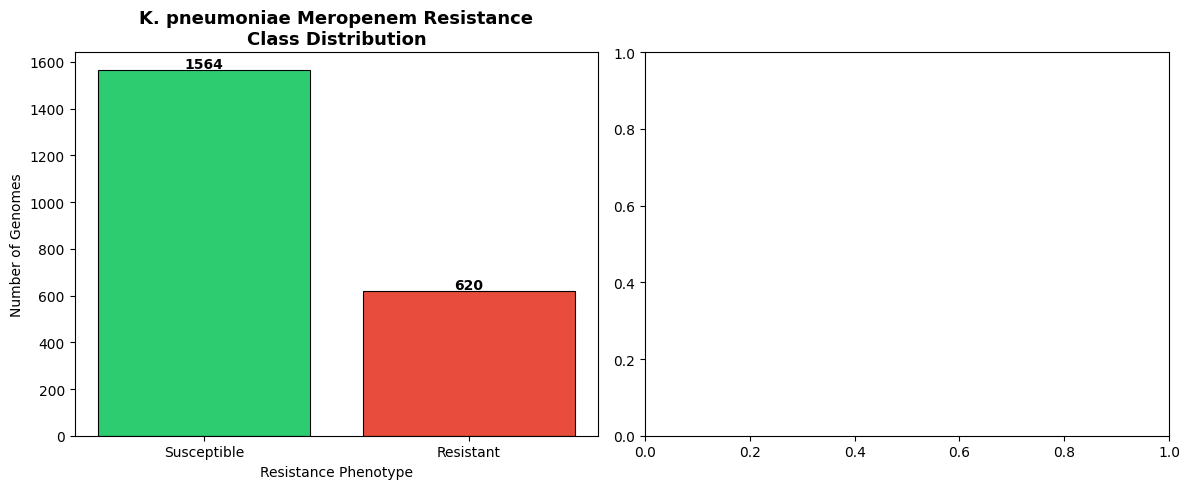

Plot saved as class_distribution.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1 — Class distribution bar chart
counts = df_clean['resistant_phenotype'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('K. pneumoniae Meropenem Resistance\nClass Distribution',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Resistance Phenotype')
axes[0].set_ylabel('Number of Genomes')
for i, (label, count) in enumerate(counts.items()):
    axes[0].text(i, count + 10, str(count), ha='center', fontweight='bold')


plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved as class_distribution.png")

## Step 3 - Download Genome Sequences

### Checking for Existing Files Before Downloading

Before initiating the file transfer, we use a quick logic check to see if the dataset is already present in our local environment or mounted Google Drive.

**Why we do this:**
Genomic datasets are incredibly large. Checking for the file first creates a "resumable download" workflow. This ensures that if the notebook runtime disconnects or restarts, we don't waste time, data, or compute power redownloading files that are already securely saved.

In [ ]:
if os.path.exists("genome_sequences.json"):
    size = os.path.getsize("genome_sequences.json") / (1024*1024)
    print(f"genome_sequences.json exists — size: {round(size, 2)} MB")
else:
    print("JSON file not found — sequences were not saved to disk")

if os.path.exists("kpn_meropenem_clean.csv"):
    print("kpn_meropenem_clean.csv exists — metadata is safe")

JSON file not found — sequences were not saved to disk
kpn_meropenem_clean.csv exists — metadata is safe


## Verify Download Integrity

The following cell does not re-download the data. Instead, it explicitly loads the saved file into memory to verify that the download completed successfully and that the file is not corrupted before we begin parsing the genomic sequences.

In [ ]:
import requests
import time
from Bio import SeqIO
from io import StringIO
from collections import defaultdict
import json

# 1. Setup
df_clean = pd.read_csv("kpn_meropenem_clean.csv")
genome_ids = [str(gid) for gid in df_clean['genome_id'].tolist()]
genome_sequences = {} # Start fresh
output_file = "genome_sequences_fixed.json"

batch_size = 10 # Smaller batches for better control
remaining_ids = genome_ids # All of them for this clean run

print(f"Starting fresh download for {len(remaining_ids)} genomes...")

for batch_num, i in enumerate(range(0, len(remaining_ids), batch_size)):
    batch = remaining_ids[i:i + batch_size]
    batch_str = ",".join(batch)

    url = f"https://bv-brc.org/api/genome_sequence/?in(genome_id,({batch_str}))&limit(10000)"

    try:
        response = requests.get(url, headers={"Accept": "application/dna+fasta"}, timeout=120)

        if response.status_code == 200 and len(response.text) > 10:
            # Parse sequences
            for record in SeqIO.parse(StringIO(response.text), "fasta"):
                # IMPROVED ID PARSING:
                # We look for the ID that looks like '1234.5' in the header
                # BV-BRC usually puts this in the record.description
                full_desc = record.description

                # Logic: Find which ID from our 'batch' is inside this description
                found_id = None
                for gid in batch:
                    if gid in full_desc:
                        found_id = gid
                        break

                if found_id:
                    if found_id not in genome_sequences:
                        genome_sequences[found_id] = ""
                    genome_sequences[found_id] += str(record.seq).lower()

            print(f"Batch {batch_num+1}: Successfully processed {len(batch)} genome IDs")

        else:
            print(f"Batch {batch_num+1}: Server returned empty or error {response.status_code}")

    except Exception as e:
        print(f"Batch {batch_num+1} failed: {e}")

    # Save checkpoint every 10 batches
    if (batch_num + 1) % 10 == 0:
        with open(output_file, "w") as f:
            json.dump(genome_sequences, f)
        print(f"--- CHECKPOINT: {len(genome_sequences)} unique genomes saved to disk ---")

    time.sleep(1) # Be polite to the server

# Final save
with open(output_file, "w") as f:
    json.dump(genome_sequences, f)
print(f"\nDONE! Total unique genomes: {len(genome_sequences)}")

In [ ]:
import json

with open("genome_sequences_fixed.json", "r") as f:
    genome_sequences = json.load(f)

print(f"Total genomes loaded: {len(genome_sequences)}")
print(f"Sample genome IDs: {list(genome_sequences.keys())[:5]}")

# Check sequence lengths
lengths = [len(seq) for seq in genome_sequences.values()]
import numpy as np
print(f"\nSequence length statistics:")
print(f"  Mean:   {round(np.mean(lengths)/1e6, 2)} million bp")
print(f"  Min:    {round(min(lengths)/1e6, 2)} million bp")
print(f"  Max:    {round(max(lengths)/1e6, 2)} million bp")

Total genomes loaded: 743
Sample genome IDs: ['573.31049', '573.83634', '72407.2453', '72407.2835', '573.18697']

Sequence length statistics:
  Mean:   5.63 million bp
  Min:    0.33 million bp
  Max:    11.66 million bp


## Step 4 - Save to Google Drive

In [ ]:
from google.colab import drive
import os
import shutil

# 1. Mount the drive
drive.mount('/content/drive')

# 2. Define the path to your project folder in Drive
# If you don't have a folder named 'AMR_Project', this will create it
drive_folder = "/content/drive/MyDrive/AMR_Project/"
if not os.path.exists(drive_folder):
    os.makedirs(drive_folder)

# 3. Move the FIXED files from the local storage to Google Drive
shutil.copy("/content/genome_sequences_fixed.json", drive_folder + "genome_sequences_fixed.json")
shutil.copy("/content/kpn_meropenem_clean.csv", drive_folder + "kpn_meropenem_clean.csv")

print(f"✅ Success! Fixed files are now safe in: {drive_folder}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Success! Fixed files are now safe in: /content/drive/MyDrive/AMR_Project/
